# L2p8_m9: Poisson scatter of $N(M_{500c}, z)$ across eight lightcones

Binned CNC product: `data/cnc/L2p8_m9_M500c_binned_multilc.npz` (15 $z$ bins, 12 log $M_{500c}$ bins, 8 lightcones).

Source catalogues: `/rds/rds-lxu/flamingo/L2p8_m9/lightcone{0..7}/catalogues/`
(`M_{500c}\ge10^{13}\,M_\odot$, $0\le z\le 3$). Rebuild with `scripts/bin_cnc_L2p8_m9_Mz_multilc.py`.

For each bin we compare the **mean** and **sample std** of the eight observer counts to the
Poisson expectation $\sigma_N=\sqrt{\langle N\rangle}$:

1. $N(M_{500c})$ in selected $z$ slices
2. $N(z)$ marginal over mass

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

DATA_NPZ = Path("/scratch/scratch-lxu/flamingo_repo/data/cnc/L2p8_m9_M500c_binned_multilc.npz")
N_OBS = 8
Z_SLICE_IDX = [2, 5, 8, 11]  # z panels for N(M)

data = np.load(DATA_NPZ)
counts_lc = data["counts_lc"]
Z_EDGES = data["bins_edges_z"]
M_EDGES = data["bins_edges_M"]
N_Z, N_M = len(Z_EDGES) - 1, len(M_EDGES) - 1
print(f"loaded {DATA_NPZ.name}: counts_lc {counts_lc.shape}, total {counts_lc.sum():,}")

loaded L2p8_m9_M500c_binned_multilc.npz: counts_lc (8, 15, 12), total 198,248,921


In [2]:
def observer_stats(counts_1d: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mean = counts_1d.mean(axis=0)
    std = counts_1d.std(axis=0, ddof=1)
    poisson = np.sqrt(np.maximum(mean, 0.0))
    return mean, std, poisson


M_CENT = np.sqrt(M_EDGES[:-1] * M_EDGES[1:])
Z_CENT = 0.5 * (Z_EDGES[:-1] + Z_EDGES[1:])
M_XLIM = (float(M_EDGES[0]), float(M_EDGES[-1]))
Z_XLIM = (float(Z_EDGES[0]), float(Z_EDGES[-1]))


def log_ylim_from_values(values: np.ndarray, *, floor: float = 0.8, ceil: float = 2.0) -> tuple[float, float]:
    pos = values[values > 0]
    if pos.size == 0:
        return 1.0, 10.0
    return float(pos.min()) * floor, float(pos.max()) * ceil


def plot_mean_poisson(
    ax,
    x: np.ndarray,
    mean: np.ndarray,
    std: np.ndarray,
    poisson: np.ndarray,
    *,
    xscale: str = "log",
    yscale: str = "log",
    show_lc: bool = True,
    lc_counts: np.ndarray | None = None,
) -> None:
    """Mean ± std across lightcones; Poisson √⟨N⟩ as error bars (not a dashed line)."""
    mask = mean > 0
    x, mean, std, poisson = x[mask], mean[mask], std[mask], poisson[mask]

    if show_lc and lc_counts is not None:
        lc = lc_counts[:, mask]
        pois_lc = np.sqrt(np.maximum(lc, 0.0))
        for obs in range(lc.shape[0]):
            ax.errorbar(
                x, lc[obs], yerr=pois_lc[obs], fmt=".",
                ms=2, alpha=0.35, color="0.55", capsize=1, elinewidth=0.6,
                zorder=1,
            )

    ax.errorbar(
        x, mean, yerr=poisson, fmt="none",
        ecolor="C3", capsize=3, capthick=1.2, elinewidth=1.2,
        label=r"Poisson $\sqrt{\langle N\rangle}$", zorder=2,
    )
    ax.errorbar(
        x, mean, yerr=std, fmt="o",
        ms=5, mfc="C0", mec="C0", ecolor="C0",
        capsize=4, capthick=1.4, elinewidth=1.4,
        label=r"mean $\pm$ std (8 lc)", zorder=3,
    )
    if xscale:
        ax.set_xscale(xscale)
    if yscale:
        ax.set_yscale(yscale)


def set_mass_axis(ax, y_values: np.ndarray | None = None) -> None:
    ax.set_xscale("log")
    ax.set_xlim(M_XLIM)
    if y_values is not None:
        ax.set_yscale("log")
        ax.set_ylim(log_ylim_from_values(y_values))

## $N(M_{500c})$ in selected $z$ bins

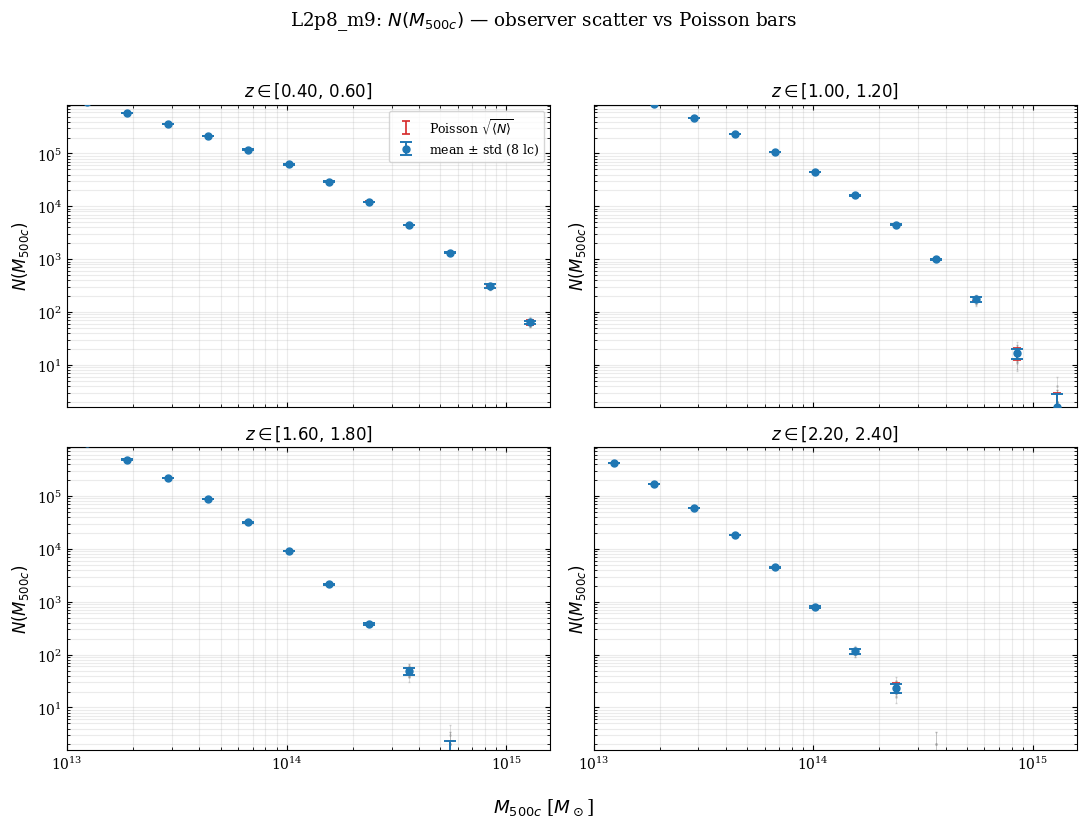

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for ax, zi in zip(axes.ravel(), Z_SLICE_IDX):
    z_lo, z_hi = Z_EDGES[zi], Z_EDGES[zi + 1]
    mean, std, poisson = observer_stats(counts_lc[:, zi, :])
    plot_mean_poisson(
        ax, M_CENT, mean, std, poisson,
        xscale=None, yscale=None,
        lc_counts=counts_lc[:, zi, :],
    )
    set_mass_axis(ax, counts_lc[:, zi, :])
    ax.set_title(rf"$z \in [{z_lo:.2f},\,{z_hi:.2f}]$")
    ax.set_ylabel(r"$N(M_{500c})$")
    ax.grid(True, which="both", alpha=0.25)
fig.supxlabel(r"$M_{500c}$ [$M_\odot$]")
axes[0, 0].legend(loc="upper right")
fig.suptitle(r"L2p8_m9: $N(M_{500c})$ — observer scatter vs Poisson bars", y=1.02)
fig.tight_layout()
plt.show()

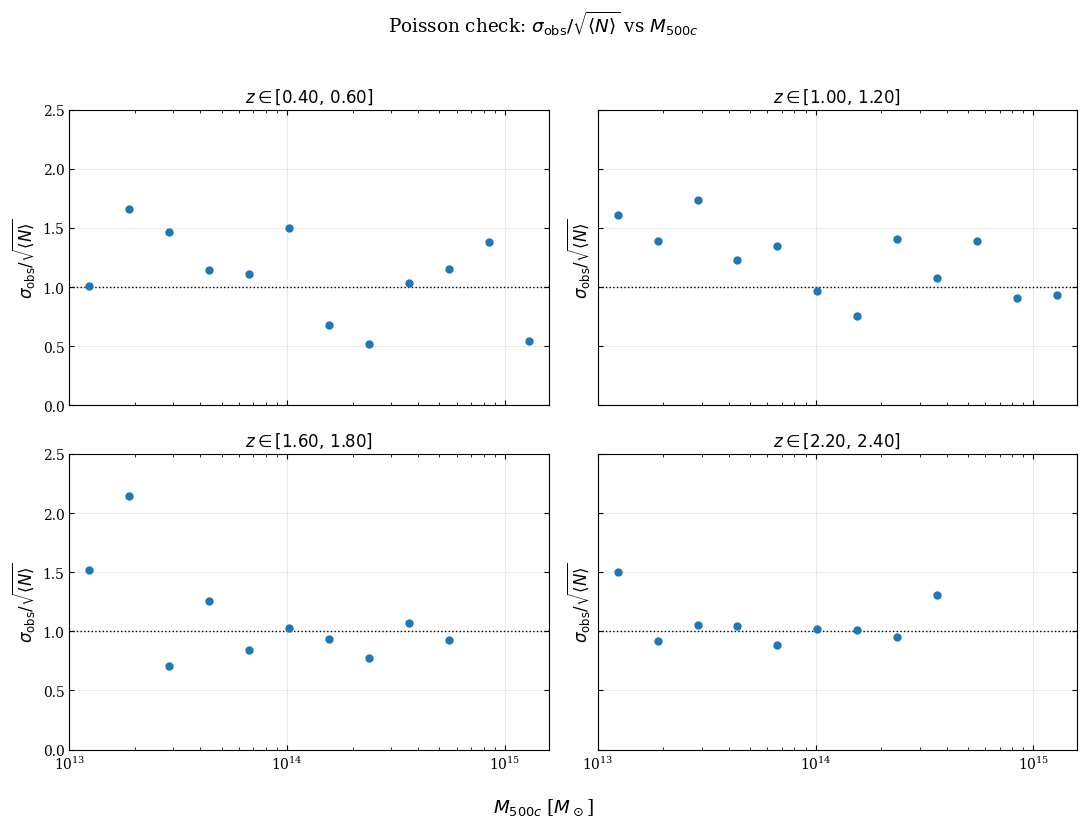

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, zi in zip(axes.ravel(), Z_SLICE_IDX):
    z_lo, z_hi = Z_EDGES[zi], Z_EDGES[zi + 1]
    mean, std, poisson = observer_stats(counts_lc[:, zi, :])
    ok = (mean > 0) & (poisson > 0)
    ratio = np.full_like(mean, np.nan)
    ratio[ok] = std[ok] / poisson[ok]
    ax.axhline(1.0, color="k", ls=":", lw=1)
    ax.plot(M_CENT[ok], ratio[ok], "o", ms=5, mfc="C0", mec="C0")
    ax.set_xscale("log")
    ax.set_xlim(M_XLIM)
    ax.set_ylim(0, 2.5)
    ax.set_title(rf"$z \in [{z_lo:.2f},\,{z_hi:.2f}]$")
    ax.set_ylabel(r"$\sigma_{\rm obs}/\sqrt{\langle N\rangle}$")
    ax.grid(True, alpha=0.25)
fig.supxlabel(r"$M_{500c}$ [$M_\odot$]")
fig.suptitle(r"Poisson check: $\sigma_{\rm obs}/\sqrt{\langle N\rangle}$ vs $M_{500c}$", y=1.02)
fig.tight_layout()
plt.show()

## $N(z)$ marginal over $M_{500c}$

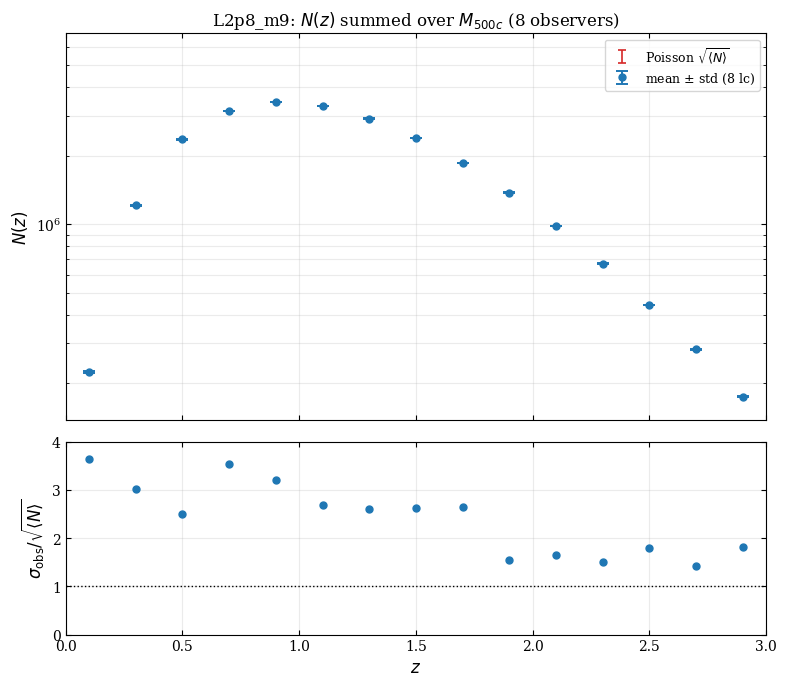

In [5]:
n_z_obs = counts_lc.sum(axis=2)
mean_z, std_z, poisson_z = observer_stats(n_z_obs)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
plot_mean_poisson(
    ax0, Z_CENT, mean_z, std_z, poisson_z,
    xscale=None, yscale=None, lc_counts=n_z_obs,
)
ax0.set_xlim(Z_XLIM)
ax0.set_yscale("log")
ax0.set_ylim(log_ylim_from_values(n_z_obs))
ax0.set_ylabel(r"$N(z)$")
ax0.legend(loc="upper right")
ax0.grid(True, which="both", alpha=0.25)
ax0.set_title(r"L2p8_m9: $N(z)$ summed over $M_{500c}$ (8 observers)")

ok = (mean_z > 0) & (poisson_z > 0)
ratio_z = np.full_like(mean_z, np.nan)
ratio_z[ok] = std_z[ok] / poisson_z[ok]
ax1.axhline(1.0, color="k", ls=":", lw=1)
ax1.plot(Z_CENT[ok], ratio_z[ok], "o", ms=5, mfc="C0", mec="C0")
ax1.set_xlim(Z_XLIM)
ax1.set_ylim(0, 4)
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$\sigma_{\rm obs}/\sqrt{\langle N\rangle}$")
ax1.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

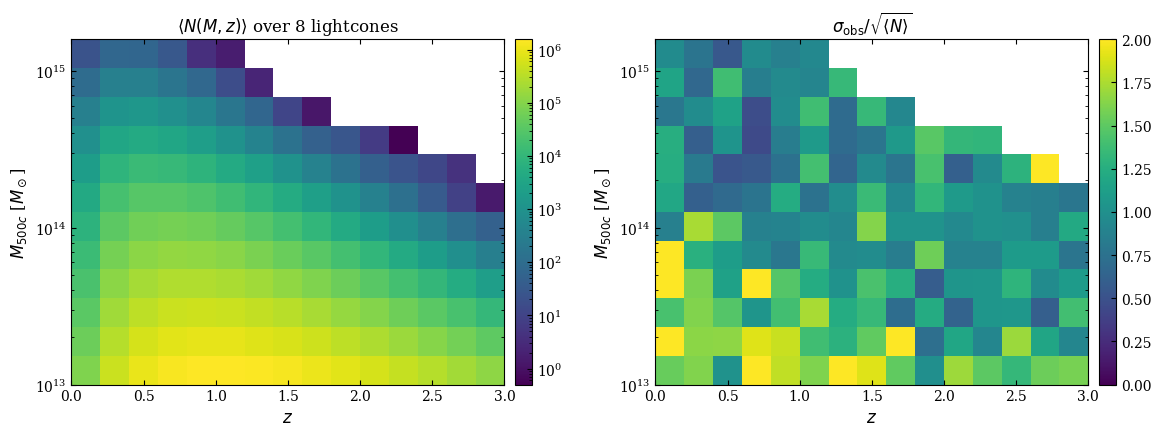

In [6]:
mean_2d = counts_lc.mean(axis=0)
std_2d = counts_lc.std(axis=0, ddof=1)
poisson_2d = np.sqrt(np.maximum(mean_2d, 0.0))
ratio_2d = np.divide(std_2d, poisson_2d, out=np.full_like(std_2d, np.nan), where=poisson_2d > 0)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = ax0.pcolormesh(Z_EDGES, M_EDGES, mean_2d.T, norm=plt.matplotlib.colors.LogNorm())
ax0.set_yscale("log")
ax0.set_xlabel(r"$z$")
ax0.set_ylabel(r"$M_{500c}$ [$M_\odot$]")
ax0.set_title(r"$\langle N(M,z)\rangle$ over 8 lightcones")
fig.colorbar(im0, ax=ax0, pad=0.02)

im1 = ax1.pcolormesh(Z_EDGES, M_EDGES, ratio_2d.T, vmin=0, vmax=2)
ax1.set_yscale("log")
ax1.set_xlabel(r"$z$")
ax1.set_ylabel(r"$M_{500c}$ [$M_\odot$]")
ax1.set_title(r"$\sigma_{\rm obs}/\sqrt{\langle N\rangle}$")
fig.colorbar(im1, ax=ax1, pad=0.02)
fig.tight_layout()
plt.show()